In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

### readin the prepared excel from previous steps

In [3]:
df_full = pd.read_excel("plot_rankshift_hydro_v2_reservoir.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])


### pairwise GAP plot 

#### function

In [13]:
### updated function with both GAP magnitude and direction

# ============================================================
# Global SSP display mapping (used in ALL plots)
# ============================================================
SSP_LABEL_MAP = {
    "SSP1-VLLO": "SSP1-19",
    "SSP2-M":    "SSP2-45",
    "SSP5-H":    "SSP5-85",
}

def format_ssp(ssp: str) -> str:
    """Return standardized display name for SSP."""
    return SSP_LABEL_MAP.get(ssp, ssp)





def plot_pairwise_gaps_grid_directional(
    df_long,
    country,
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=None,
    metric_labels=None,
    pairs=None,
    gap_threshold_pct=5.0,
    figsize=(14, 10),
    size_scale=45,
    pad_ylim_adjust = 90, 
    directional=True,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if metric_labels is None:
        metric_labels = {m: m for m in metric_order}

    if pairs is None:
        raise ValueError("You must provide `pairs`, e.g. (('PV','Wind'), ('Hydro','PV'))")

    # ------------------------------------------------------------------
    # Dynamic, order-safe styling from `pairs`
    # ------------------------------------------------------------------
    marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]
    gray_cycle   = ["0.25", "0.45", "0.65", "0.35", "0.55", "0.75"]

    marker_map = {}
    gray_map   = {}

    for i, (a, b) in enumerate(pairs):
        label = f"{a} vs {b}"
        marker_map[label] = marker_cycle[i % len(marker_cycle)]
        gray_map[label]   = gray_cycle[i % len(gray_cycle)]

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(years),
        figsize=figsize,
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.20)

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    for i, ssp in enumerate(ssps):
        for j, year in enumerate(years):

            ax = axes[i, j]

            sub = df_long[
                (df_long["Country"] == country) &
                (df_long["SSP"] == ssp) &
                (df_long["Year"] == year)
            ]

            if sub.empty:
                ax.set_axis_off()
                continue

            x = np.arange(len(metric_order))

            for (a, b) in pairs:
                label = f"{a} vs {b}"
                gaps = []

                for m in metric_order:
                    sm = sub[sub["Metric"] == m].set_index("Technology")["Score"]

                    if a in sm.index and b in sm.index:
                        sa, sb = float(sm.loc[a]), float(sm.loc[b])
                        mag = abs(sa - sb) / max(sa, sb) * 100.0

                        if directional:
                            gap = +mag if sa < sb else -mag
                        else:
                            gap = mag
                        gaps.append(gap)
                    else:
                        gaps.append(np.nan)

                gaps = np.array(gaps, dtype=float)

                ax.scatter(
                    x,
                    gaps,
                    s=size_scale * np.sqrt(np.abs(gaps)),
                    marker=marker_map[label],
                    facecolor=gray_map[label],
                    edgecolor="black",
                    linewidth=0.8,
                    alpha=0.9,
                    zorder=5,
                    label=label if (i == 0 and j == 0) else None,
                )

            # ------------------------------------------------------------------
            # Reference lines
            # ------------------------------------------------------------------
            ax.axhline(0, color="black", linewidth=0.9)
            ax.axhline(+gap_threshold_pct, linestyle="--", color="red", alpha=0.7)
            ax.axhline(-gap_threshold_pct, linestyle="--", color="red", alpha=0.7)

            # ------------------------------------------------------------------
            # Formatting
            # ------------------------------------------------------------------
            #ax.set_title(f"{country}, {ssp}, {year}", fontsize=12)
            ax.set_title(
                f"{country}, {format_ssp(ssp)}, {year}",
                fontsize=12
            )
            
            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=20,
                    ha="right",
                    fontsize=10,
                )
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(
                    "Directional pairwise gap (%)\n(+ = first tech lower GWP)",
                    fontsize=11,
                )

            #ax.grid(axis="y", linestyle=":", alpha=0.35)
            # NEW Y-axis ticks and labels (fixed, symmetric, percentage)
            #ax.set_yticks([-60, -35, 0, 30, 60])
            #ax.set_yticklabels(["-60%", "-30%", "0%", "30%", "60%"], fontsize=12)
            ax.set_yticks([-50, 0, 50])
            ax.set_yticklabels(["-50%", "0%", "50%"], fontsize=12)
            
            # Darker, clearer gridlines
            ax.grid(
                axis="y",
                linestyle=":",
                linewidth=0.9,
                color="0.5",
                alpha=0.9
            )


    # ---------------------------------------------------
    # Fix y-limits to account for marker size
    # ---------------------------------------------------
    all_gaps = df_long[
        (df_long["Country"] == country) &
        (df_long["SSP"].isin(ssps)) &
        (df_long["Year"].isin(years))
    ]["Score"]
    
    # Conservative padding (in % points)
    ymin = df_long["Score"].min()
    ymax = df_long["Score"].max()
    pad = pad_ylim_adjust  # % points , adjusting here, to make sure all markers are shown, 90% here becaz the ymax/min is about 75% 
    for ax in axes.flat:
        ax.set_ylim(ymin - pad, ymax + pad)

    # above conservative padding (in % points) too much ylim, caz we know it's already close to 60%
    #for ax in axes.flat:
    #    ax.set_ylim(-60, 60)

    
    # ------------------------------------------------------------------
    # Legend (dynamic, directional, marker-preserving)
    # ------------------------------------------------------------------
    # ------------------------------------------------------------------
    legend_handles = []
    
    for (a, b) in pairs:
        label = f"{a} vs {b}"
    
        legend_label = (
            f"+ : {a} lower impact than {b} (by Δ %)\n"
            f"− : {a} higher impact than {b} (by Δ %)\n"
            f"Δ = |{a} − {b}| / max({a}, {b}) × 100"
        )
    
        handle = Line2D(
            [0], [0],
            marker=marker_map[label],      # marker still encodes the pair
            linestyle="None",
            markerfacecolor=gray_map[label],
            markeredgecolor="black",
            markeredgewidth=0.8,
            markersize=9,
            label=legend_label,
        )
    
        legend_handles.append(handle)
    
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(pairs),
        fontsize=11,
        frameon=True,
        bbox_to_anchor=(0.5, -0.08),
    )


    fig.suptitle(
        f"Pairwise technology gaps across metrics \n red lines show the 5% gap",
        fontsize=15,
        y=0.95,
    )

    return fig, axes


#### plot 

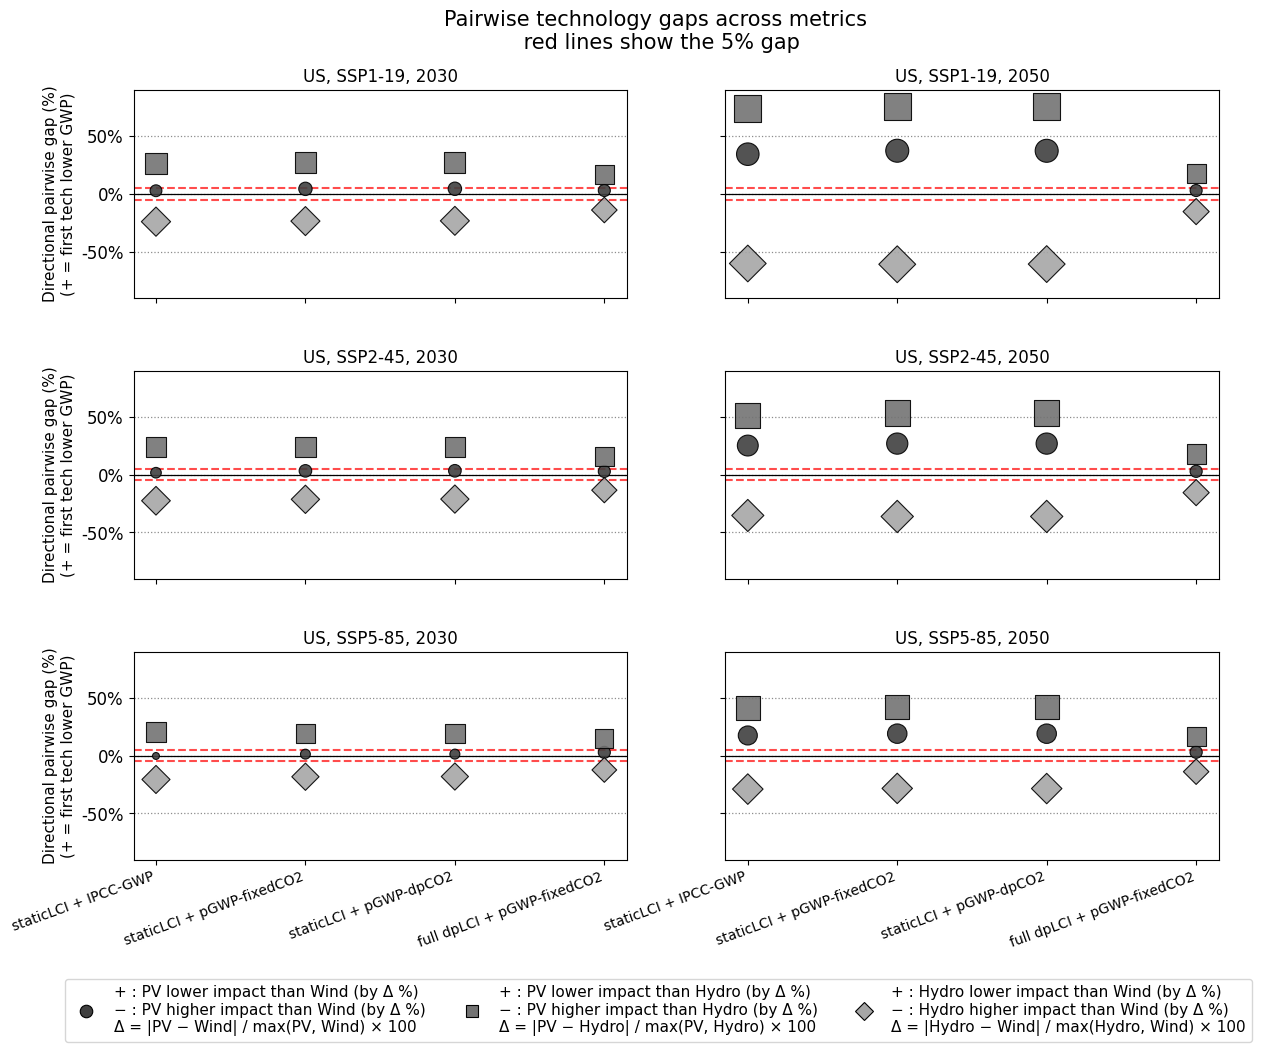

In [4]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  'staticLCI + pGWP-dpCO2', 
                  'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}


fig, axes = plot_pairwise_gaps_grid_directional(
    df_long=df_full,
    country="US",
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=metric_order,
    metric_labels=metric_labels,
    pairs=(("PV","Wind"), ( "PV", "Hydro"), ("Hydro", "Wind")),
    #directional  = TRUE 
    gap_threshold_pct=5.0,  #only if we wanna add abline 
    figsize=(14, 10),
)



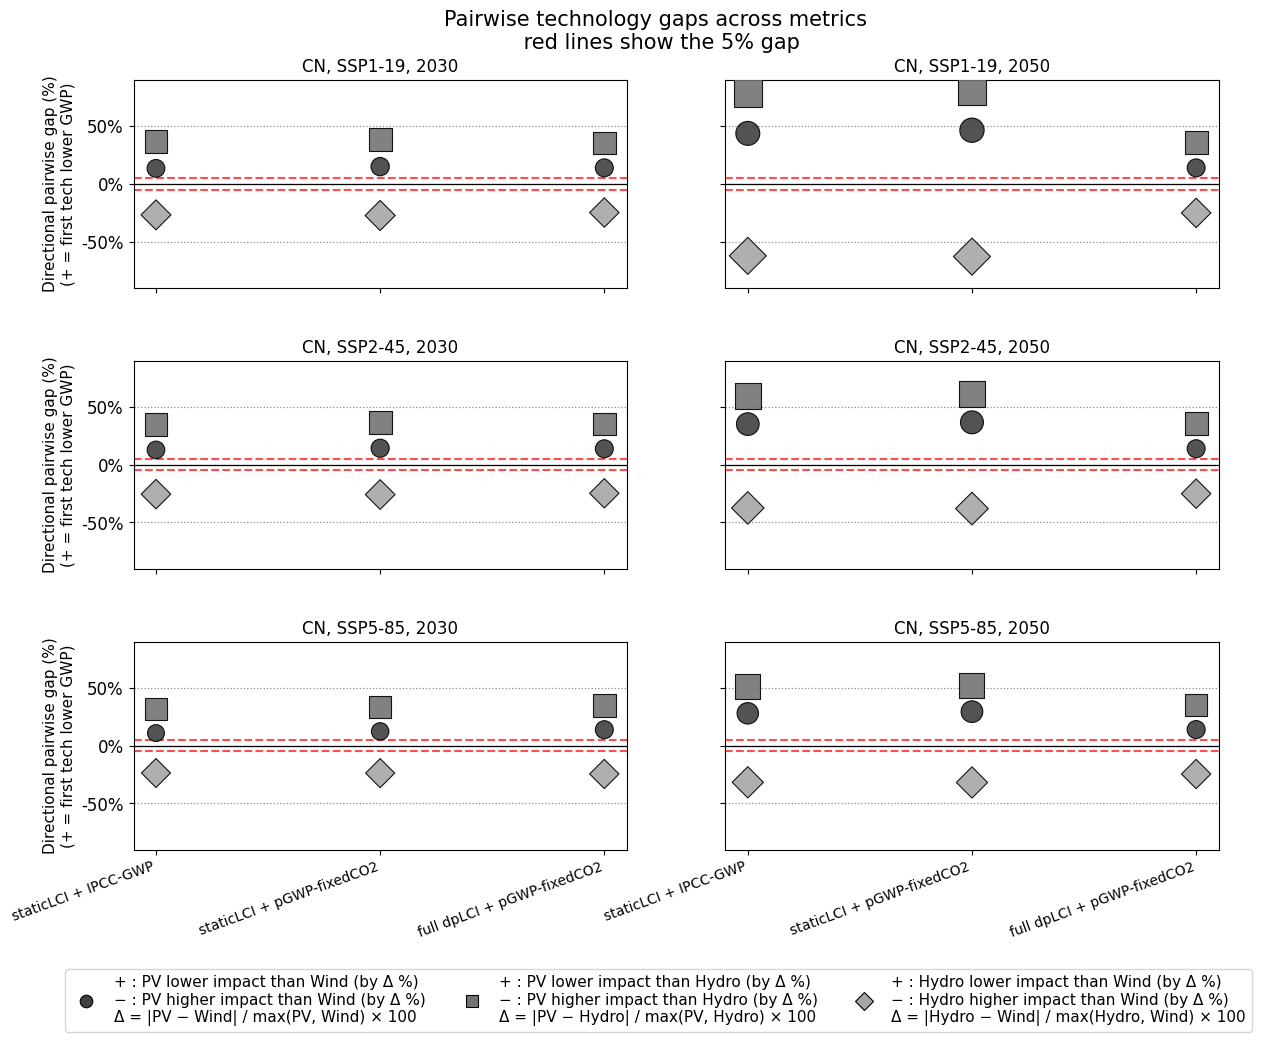

In [5]:

fig, axes = plot_pairwise_gaps_grid_directional(
    df_long=df_full,
    country="CN",
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=metric_order,
    metric_labels=metric_labels,
    pairs=(("PV","Wind"), ( "PV", "Hydro"), ("Hydro", "Wind")),
    #directional  = TRUE 
    gap_threshold_pct=5.0,  #only if we wanna add abline 
    figsize=(14, 10),
)